# Phase 2 — Quality Control (QC)

Goal: understand the incoming AnnData object and apply a defensible,
minimal cell/gene filtering step before any normalization or transformation
(handled separately in `03_preprocessing.ipynb`).

In [1]:
import pertpy as pt
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

adata = pt.dt.kang_2018()
adata

/home/maram/miniconda3/envs/single_cell/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


/home/maram/miniconda3/envs/single_cell/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/maram/miniconda3/envs/single_cell/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

## Understanding the input object

This dataset arrives already processed via `pertpy` (it is not raw FASTQ
data). Before applying any filtering or transformation, we inspect what is
actually stored in the AnnData object, rather than assuming a standard
raw-counts workflow applies unmodified.

In [2]:
print("adata.X dtype:", adata.X.dtype)
print("adata.X min/max:", adata.X.min(), adata.X.max())
print()
print("Layers:", list(adata.layers.keys()))
print()
print("obs columns:", adata.obs.columns.tolist())
print()
print("obsm keys:", list(adata.obsm.keys()))
print()
print("adata.raw:", adata.raw)

adata.X dtype: float32
adata.X min/max: 0.0 3828.0

Layers: []

obs columns: ['nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters']

obsm keys: ['X_pca', 'X_umap']

adata.raw: None


## Inspecting mitochondrial content

Mitochondrial percentage is a standard scRNA-seq QC metric used to flag
dying or stressed cells. Before relying on it, we check whether
mitochondrial genes are present in this dataset at all.

In [3]:
adata.var["mt"] = adata.var["name"].str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,24673.000000,24673.000000,24673.0
mean,574.900985,1567.192627,0.0
std,206.621105,912.257385,0.0
min,12.000000,562.000000,0.0
25%,441.000000,975.000000,0.0
50%,519.000000,1246.000000,0.0
75%,652.000000,1816.000000,0.0
max,2757.000000,11816.000000,0.0


In [4]:
adata.var["name"][adata.var["name"].str.contains("MT", case=False, na=False)].head(20)

index
ICMT                    ICMT
CAMTA1                CAMTA1
MTOR                    MTOR
MTHFR                  MTHFR
MTFR1L                MTFR1L
MTF1                    MTF1
MTF2                    MTF2
TRMT13                TRMT13
PRMT6                  PRMT6
HENMT1                HENMT1
LAMTOR5-AS1      LAMTOR5-AS1
LAMTOR5              LAMTOR5
MTMR11                MTMR11
ADAMTSL4            ADAMTSL4
ADAMTSL4-AS1    ADAMTSL4-AS1
MTX1                    MTX1
LAMTOR2              LAMTOR2
TRMT1L                TRMT1L
MTR                      MTR
DNMT3A                DNMT3A
Name: name, dtype: object

No genes matching the `MT-` prefix are present in this dataset, and no
gene names containing "MT" resemble mitochondrial genes either. This
processed release of the Kang dataset appears to have had mitochondrial
genes removed upstream, before distribution via pertpy.

**Mitochondrial QC is therefore not applicable here** and is documented as
a limitation/property of this processed dataset, rather than a step we can
perform. We rely on `total_counts` and `n_genes_by_counts` instead.

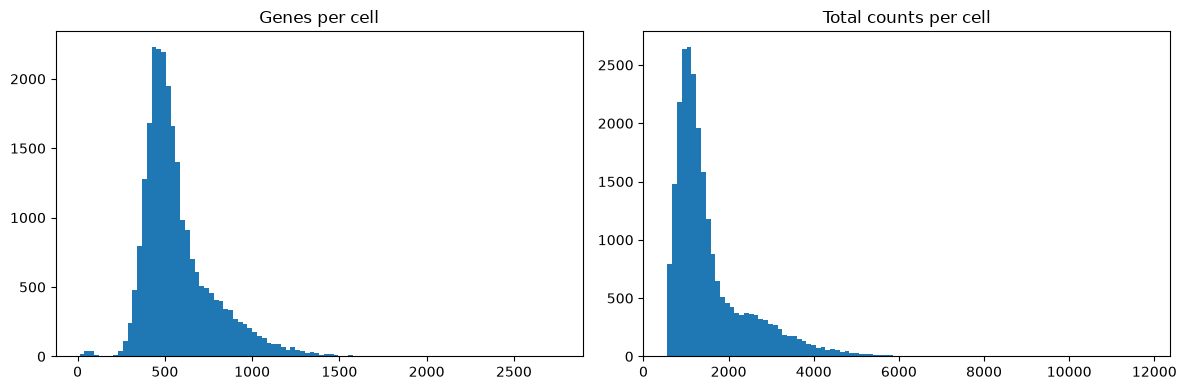

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(adata.obs["n_genes_by_counts"], bins=100)
axes[0].set_title("Genes per cell")
axes[1].hist(adata.obs["total_counts"], bins=100)
axes[1].set_title("Total counts per cell")
plt.tight_layout()
plt.show()

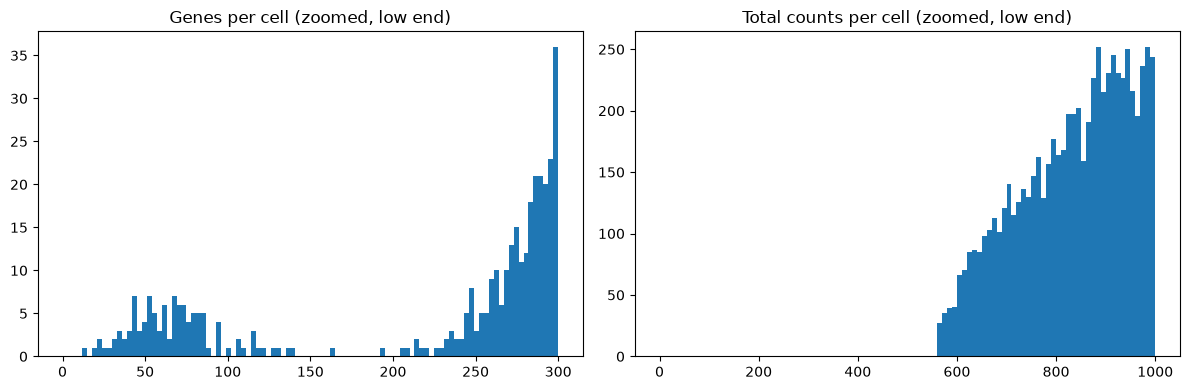

genes < 100: 97 cells
genes < 150: 109 cells
genes < 200: 111 cells
genes < 250: 142 cells
genes < 300: 376 cells


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(adata.obs["n_genes_by_counts"], bins=100, range=(0, 300))
axes[0].set_title("Genes per cell (zoomed, low end)")
axes[1].hist(adata.obs["total_counts"], bins=100, range=(0, 1000))
axes[1].set_title("Total counts per cell (zoomed, low end)")
plt.tight_layout()
plt.show()

for t in [100, 150, 200, 250, 300]:
    print(f"genes < {t}: {(adata.obs['n_genes_by_counts'] < t).sum()} cells")

## Choosing a filtering threshold

The distribution of genes detected per cell shows a small population of
likely debris/empty droplets (fewer than ~150 genes), a quiet gap, then the
main cell population starting around 250+ genes. We use `min_genes=200`, a
standard scRNA-seq floor that falls within this gap.

`total_counts` requires no additional low-end filtering: the dataset
already has no cells below ~560 counts, indicating an upstream minimum-count
filter was already applied before this processed release.

In [7]:
print(f"Before filtering: {adata.n_obs} cells")
sc.pp.filter_cells(adata, min_genes=200)
print(f"After filtering: {adata.n_obs} cells")

Before filtering: 24673 cells


After filtering: 24562 cells


In [8]:
print(f"Before filtering: {adata.n_vars} genes")
sc.pp.filter_genes(adata, min_cells=3)
print(f"After filtering: {adata.n_vars} genes")

Before filtering: 15706 genes


After filtering: 15701 genes


## Save checkpoint

Save the QC-filtered object so `03_preprocessing.ipynb` can load it
directly, without re-running ingestion and filtering.

In [9]:
adata.write("../results/adata_qc_filtered.h5ad")
print("Saved: results/adata_qc_filtered.h5ad")

Saved: results/adata_qc_filtered.h5ad
